(00-00-setup)=

# Opzet, data en conventies

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1863–2026 — het hele verhaal in één blik.

**Wat we al weten.** Nog niets, en dat is het punt van deze lecture. Het
verhaal begint in 1863 bij een Parijse beursemployé die opmerkt dat de
koersuitslag met de wortel van de tijd groeit, en het eindigt bij taalmodellen
die beleggingsadvies geven; daartussen liggen de random walk, het CAPM,
Black-Scholes, de equity premium puzzle, de factor zoo en de vraag of prijzen
bewegen omdat het risico verandert of omdat beleggers zich vergissen. Elk van
die episodes bestaat uit dezelfde drie ingrediënten: een theorie, een machine
die data produceert, en een barst die het volgende tijdvak in gang zet
(zie [](#index)). Deze lecture bouwt de machine: het `hap`-pakket, de acht
gratis databronnen, en de notatie waarin de rest van de reeks is geschreven.

**Welke vraag staat open.** Wat is eigenlijk een rendement, en hoe goed kunnen
we het meten?
```

## Overzicht

Deze reeks volgt de terugblik van Pedro Santa-Clara op veertig jaar asset
pricing {cite}`SantaClara2026`, en werkt die uit tot op de vergelijking, de
data en de code. De vorm is geleend van *Advanced Quantitative Economics with
Python* {cite}`SargentStachurski`: geen dictaat met opgaven achterin, maar een
tekst waarin elke bewering die telt ook wordt uitgerekend, op data die u zelf
kunt downloaden.

Dit is de enige lecture zonder eigen onderwerp. Ze legt uit hoe de andere
zevenendertig zijn opgebouwd, welke notatie overal geldt, welke data er is en
— eerlijker dan gebruikelijk — welke data er *niet* is. Aan het eind staat één
klein rekenvoorbeeld dat de rest van de reeks al in miniatuur bevat: we
schatten een gemiddeld rendement, en zetten er de standaardfout bij. Dat getal,
ongeveer twee procentpunt, is het motief dat in bijna elke volgende lecture
terugkomt.

Er wordt hier niets gerepliceerd. Wel wordt elke databron één keer geladen en
één keer getekend, zodat u weet wat er in de kast staat voordat we hem gaan
gebruiken. De epistemische status van deze lecture is dus die van een
gereedschapskist: er staat geen enkele bewering in die falsifieerbaar is, en
alle beweringen die verderop wél falsifieerbaar zijn, worden met dit
gereedschap getoetst.

De imports-cel hieronder staat in elke lecture bovenaan en bevat alle imports.
Verderop wordt nergens meer geïmporteerd.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## De rode draad, en hoe een lecture is opgebouwd

Het vak is chronologisch geordend maar niet cumulatief: het is niet zo dat elk
decennium een steen op de vorige legde. Wat er gebeurde is telkens hetzelfde
patroon. Iemand formuleert een theorie. Er komt een machine die data produceert
waarmee die theorie voor het eerst getoetst kan worden — de CRSP-tape in 1964,
de optiebeurs in 1973, Compustat, de dagelijkse volatiliteitsreeksen van de
jaren negentig, de open datasets van nu. En dan blijkt er een feit te zijn dat
het model niet aankan. Dat feit is de barst, en de barst is de reden dat er een
volgend hoofdstuk is.

Drie motieven lopen door het hele verhaal heen, en ze zijn de reden dat deze
reeks bestaat in plaats van een handboek.

**De standaardfout van 2%.** Het gemiddelde rendement van de aandelenmarkt is
met een eeuw data nog steeds slecht gemeten. Bij een volatiliteit van ongeveer
18% per jaar en honderd jaar data is de standaardfout van het gemiddelde
$18/\sqrt{100} \approx 1{,}8$ procentpunt. De variantie daarentegen is
uitstekend meetbaar, en met dagdata bijna exact. Dat ene asymmetrische feit
verklaart opvallend veel: waarom volatiliteit voorspelbaar is en rendement
nauwelijks, waarom de equity premium puzzle niet met meer data verdwijnt, en
waarom het mogelijk is honderden "factoren" te publiceren die allemaal
significant lijken. We rekenen het aan het eind van deze lecture één keer voor
en komen er daarna in bijna elke lecture op terug.

**Risico versus vergissing.** Aandelen zijn goedkoop na een crash. Chicago
leest dat als: beleggers eisen dan een hogere vergoeding, de discontovoet is
gestegen. Yale leest hetzelfde feit als: beleggers zijn bang, de prijs zit
ernaast. Beide kampen zijn het eens over de metingen en oneens over de
interpretatie, en in 2013 kregen Fama en Shiller samen de Nobelprijs — geen
compromis, maar een correcte beschrijving van de stand van zaken. In elke
lecture waar dit speelt geven we beide lezingen, en we kiezen niet voor u.

**Van theorie-met-tests naar feiten-met-concurrerende-theorieën.** Het vak
begon met één model dat werd getoetst en eindigt met een verzameling robuuste
feiten waarvoor meerdere modellen zich aandienen. Bij elk model in deze reeks
staat daarom expliciet welke status het heeft: is dit een theorie die aan data
wordt onderworpen, of een feit dat op een verklaring wacht?

Daaronder ligt een praktische les die Santa-Clara zelf trekt: *"Everything I
made that lasted came from bearing risk that was priced. Everything I lost came
from thinking I knew something the price did not."* Waar een lecture over een
handelsstrategie gaat, stellen we die vraag hardop.

### De didactische trap

Elke inhoudelijke lecture heeft dezelfde vaste opbouw, en die opbouw is geen
formaliteit maar een didactische keuze. Na *Waar we zijn in het verhaal* en het
*Overzicht* volgt eerst *Intuïtie: waarom zou dit waar zijn?* — het mechanisme
in gewone taal, zonder één symbool. Daarna komt de trap, in drie treden:

1. **Toy-voorbeeld.** Het kleinste geval waarin het mechanisme al zichtbaar is:
   twee toestanden en drie activa, een binomiale boom van drie stappen, drie
   observaties en één regressor. Eerst met de hand uitgerekend, met de getallen
   in de tekst; daarna een codecel die exact dezelfde getallen reproduceert.
   Die controle is de reden dat u de rest van de code mag vertrouwen.
2. **Theorie.** De algemene stelling, met bewijs. Elke afleiding begint met de
   cursieve regel *Waarom zou dit waar zijn?* en een economisch argument van
   een paar zinnen, en pas daarna de wiskunde. Wie de wiskunde overslaat moet
   het resultaat nog steeds kunnen navertellen.
3. **Simulatie.** Hetzelfde model, maar op schaal en in *steekproeven*:
   duizenden paden, honderden activa, tienduizend herhalingen. Hier zien we
   niet wat waar is, maar wat meetbaar is — schattingsfout, bias, datamining.
   Dit is bijna altijd de plek waar het 2%-motief terugkomt.
4. **Replicatie op echte data.** Pas hier verschijnt `hap.data`, met een
   replicatieblok dat zegt welk paperresultaat we nabouwen, met welke data, wat
   het verschil met het origineel is, en — het belangrijkste — welke afwijking
   we verwachten. Een replicatie zonder falsifieerbare verwachting is geen
   replicatie.

De volgorde is niet vrijblijvend. Wie meteen met een regressie op French-data
begint, leert een procedure; wie eerst het toy-voorbeeld narekent en dan de
steekproefverdeling ziet, leert een mechanisme en kan daarna zelf beoordelen
wat een tabel op echte data betekent.

Elke lecture sluit met *Wat er brak, en wat daarna kwam* — wat het model
verklaart, waar het breekt, hoe beide kampen die barst lezen, en welke lecture
er daarom op volgt — en met twee tot vier oefeningen op problem-set-niveau, elk
met een uitwerking in een opklapbaar blok.

## Notatie

De hele reeks deelt één notatie. Wijkt een origineel paper daarvan af, dan
vertalen we naar de tabel hieronder en zeggen dat in één zin. Het loont de
moeite deze tabel één keer door te lezen; hij wordt verder nergens herhaald.

| Symbool | Betekenis |
|---|---|
| $p_t$ | prijs op tijdstip $t$ |
| $x_{t+1}$ | payoff op $t+1$; per definitie $R_{t+1} = x_{t+1}/p_t$ |
| $R_{t+1}$ | bruto rendement, $R = 1 + r$ |
| $r_{t+1}$ | netto rendement; een kleine letter is een log-grootheid waar dat is aangekondigd |
| $R^{f}_{t+1}$ | bruto risicovrij rendement, al bekend op $t$ |
| $R^{e}_{t+1}$ | excess rendement, $R^{e} = R - R^{f}$ |
| $m_{t+1}$ | stochastic discount factor, $m_{t+1} = \beta\,u'(c_{t+1})/u'(c_t)$ |
| $d_t$, $c_t$ | dividend, consumptie |
| $u(\cdot)$, $\gamma$, $\beta$ | nutsfunctie, relatieve risicoaversie, subjectieve discontofactor |
| $\beta_{i,f}$ | bèta van activum $i$ op factor $f$ — altijd met twee indices |
| $\lambda_f$ | prijs van risico van factor $f$ |
| $\alpha_i$ | pricing error, oftewel Jensen-alpha |
| $f_{t+1}$ | factorrendement |
| $\mathrm{PD}_t = p_t/d_t$ | prijs-dividend-ratio; $\mathrm{DP}_t$ is het omgekeerde |
| $\mu,\ \sigma$ | verwachting en standaarddeviatie van rendementen |
| $\E_t[\cdot]$ | verwachting gegeven de informatie op $t$ |
| $\Var,\ \Cov,\ \Corr$ | variantie, covariantie, correlatie |

Drie afspraken die vaker misgaan dan u zou denken.

**Tijdsindexering.** Prijzen en informatie krijgen index $t$, payoffs en
rendementen index $t+1$. De centrale vergelijking van de hele reeks is dus

```{math}
:label: eq-setup-euler
p_t = \E_t\!\left[m_{t+1}\,x_{t+1}\right],
```

nooit $p_t = \E[m_t x_t]$. Een rendement met subscript $t+1$ wordt *verdiend*
tussen $t$ en $t+1$ en is op $t$ nog onbekend. Zodra een schatting die regel
overtreedt, kijkt de schatter in de toekomst; de helft van alle te mooie
resultaten in de empirische finance komt daarvandaan.

**Vet en cursief.** Vectoren zijn vet en klein ($\mathbf{r}$,
$\boldsymbol{\beta}$), matrices vet en groot ($\boldsymbol{\Sigma}$,
$\mathbf{X}$), scalairen gewoon cursief. Logaritmen krijgen kleine letters:
$r = \log R$, $p = \log P$, $d = \log D$. Omdat $p_t$ ook de prijs in niveaus
is, kondigt elke sectie die op logs overstapt dat expliciet aan.

**Nederlands en Engels.** De tekst is Nederlands, de code Engels. Vaktermen
blijven Engels waar een vertaling gekunsteld is — *stochastic discount factor*,
momentum, carry, value, size, hedge, spread, mispricing, limits of arbitrage,
event study, factor zoo — en worden de eerste keer in elke lecture cursief
gezet met een korte uitleg erbij. Nederlands blijven in elk geval: rendement,
rente, prijs, dividend, consumptie, risicoaversie, discontovoet, standaardfout,
steekproef, schatter, regressie, portefeuille.

```{note}
In de lopende tekst schrijven we decimalen met een komma ("8,5%"); in
code-output blijft de Engelse punt staan, want die komt uit pandas.
```

## De data

Alle data in deze reeks is gratis en publiek, en alle data komt binnen via
`hap.data`. Er staat nergens een `requests`-aanroep of een
`pd.read_csv("http://...")` in een lecture. Dat is geen netheid om de netheid:
elke loader schrijft een parquet-snapshot naar `data/cache/`, die snapshots
zijn meegecommit, en daardoor draait een verse kloon van dit project elke
lecture zonder netwerkverbinding. Zet `HAP_OFFLINE=1` en downloaden is
verboden; ontbreekt de snapshot, dan krijgt u een `hap.CacheMissError` in
plaats van stilzwijgend andere data.

Twee conventies gelden voor alle loaders. Elke frame heeft een
`DatetimeIndex` met naam `date` — maanddata op maandeinde, dagdata op de
handelsdatum. En rendementen en yields zijn **decimalen**, geen procenten:
1,5% is `0.015`. De enige uitzondering is `hap.fred`, dat FRED's eigen eenheden
teruggeeft omdat die per serie verschillen; rentes komen daar dus in procenten
binnen.

| Bron | Wat | Loader |
|---|---|---|
| Kenneth French Data Library | factoren en portefeuilles, 1926– | `hap.french(name, freq, table)` |
| Robert Shiller | S&P-prijs, dividend, winst, CAPE, 1871– | `hap.shiller()` |
| Goyal-Welch | voorspellers van de equity premium, 1871– | `hap.goyal_welch(freq)` |
| FRED | macro, rentes, VIX, wisselkoersen | `hap.fred(series)` |
| Gürkaynak-Sack-Wright | zero-coupon yieldcurve, 1961– | `hap.gsw()` |
| Open Source Asset Pricing | 212 anomalieportefeuilles + documentatie | `hap.osap(kind)` |
| He-Kelly-Manela | intermediary capital ratio, 1970– | `hap.hkm(freq)` |
| Yahoo Finance | recente koersen en optieketens | `hap.yahoo(...)`, `hap.yahoo_options(...)` |

### Kenneth French: de factoren, 1926–

De Data Library van Kenneth French is het werkpaard van de empirische asset
pricing. Ze bevat de marktfactor, de factoren uit het driefactormodel
{cite}`FamaFrench1993` en zijn vijffactoruitbreiding, momentum, reversal, en
tientallen portefeuilles gesorteerd op grootte, boek-marktwaarde,
winst-prijsverhouding en industrie — maandelijks vanaf juli 1926 en dagelijks
vanaf dezelfde datum.

`hap.market_monthly()` is een gemakshulpje bovenop `hap.french`: het geeft de
marktfactor `Mkt-RF`, de risicovrije rente `RF` en hun som `Mkt`. Meteen
daarbij de samenvattende statistieken, want in deze reeks staat er geen
gemiddeld rendement in een tabel zonder zijn standaardfout ernaast.

In [2]:
market = hap_data.market_monthly()
hap.summary_stats(market, "monthly")[
    ["nobs", "mean_ann", "std_ann", "se_mean_ann", "sharpe_ann"]
].round(4)

,nobs,mean_ann,std_ann,se_mean_ann,sharpe_ann
Mkt-RF,1201,0.08329,0.183719,0.018364,0.453354
RF,1201,0.032424,0.008597,0.000859,3.771343
Mkt,1201,0.115714,0.183371,0.018329,0.631034


Daar staat het motief al, in de eerste tabel van de reeks. Het gemiddelde
marktrendement over honderd jaar is 11,6% per jaar, de standaarddeviatie 18,3%,
en de standaardfout van dat gemiddelde 1,8 procentpunt. Een tweezijdig
95%-interval voor het gemiddelde loopt dus ruwweg van 8% tot 15% — een marge
die het verschil is tussen een markt die de moeite waard is en een die
spectaculair is. De risicovrije rente is daarentegen tot op een tiende
procentpunt bekend.

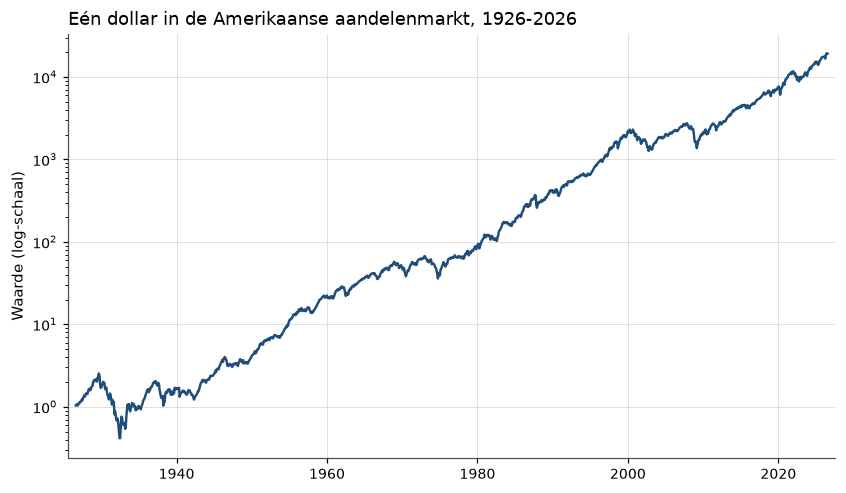

In [3]:
wealth = hap.drawdowns(market["Mkt"])

fig, ax = plt.subplots()
ax.plot(wealth.index, wealth["wealth"])
ax.set_yscale("log")
ax.set_title("Eén dollar in de Amerikaanse aandelenmarkt, 1926-2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde (log-schaal)")
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-french
:label: fig-setup-french
:width: 90%

Cumulatieve waarde van één dollar, herbelegd in de value-weighted markt. De
log-schaal maakt gelijke procentuele bewegingen even groot; op een lineaire
schaal zou alles vóór 1980 een vlakke lijn zijn. De diepste terugval in deze
reeks is 83,7%, met dieptepunt in juni 1932.
:::

### Robert Shiller: prijzen en dividenden, 1871–

Shiller's maandreeks gaat een halve eeuw verder terug dan French en bevat wat
French niet heeft: naast de prijs ook het dividend, de winst, de consumentenprijsindex
en de lange rente {cite}`Shiller2000`. Daarmee kunnen we prijzen aan
*fundamentals* koppelen in plaats van alleen aan elkaar — de voorwaarde voor
alles wat met waardering, voorspelbaarheid en excess volatility te maken heeft.
De bekendste afgeleide reeks is de CAPE, de prijs gedeeld door het
tienjaarsgemiddelde van de reële winst.

In [4]:
shiller = hap_data.shiller()
shiller[["price", "dividend", "earnings", "cape", "dp"]].dropna().iloc[[0, -1]].round(3)

,price,dividend,earnings,cape,dp
date,,,,,
1881-01-31,6.190,0.265,0.486,18.474,0.043
2026-06-30,7450.033,81.703,295.388,40.150,0.011


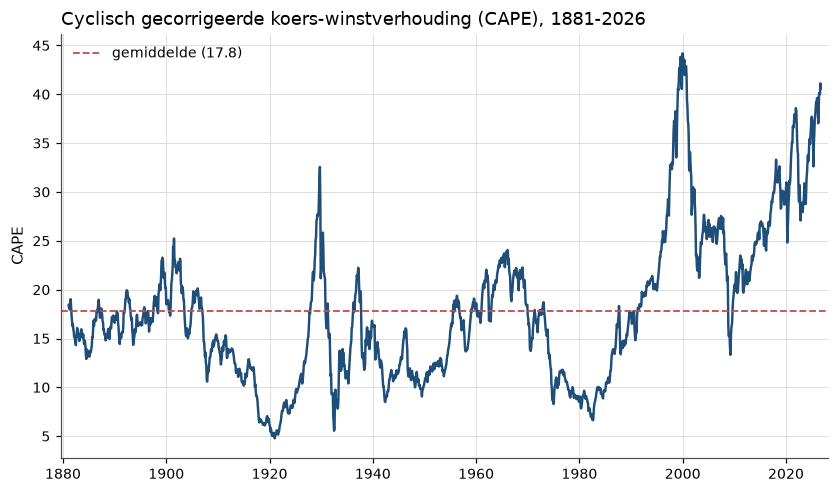

In [5]:
cape = shiller["cape"].dropna()

fig, ax = plt.subplots()
ax.plot(cape.index, cape)
ax.axhline(cape.mean(), color=hap.plotting.COLORS[1], ls="--", lw=1.2,
           label=f"gemiddelde ({cape.mean():.1f})")
ax.set_title("Cyclisch gecorrigeerde koers-winstverhouding (CAPE), 1881-2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("CAPE")
ax.legend()
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-shiller
:label: fig-setup-shiller
:width: 90%

De CAPE schommelt over decennia rond een gemiddelde van ongeveer 17,8 en staat
aan het eind van de steekproef op ruim 40. Of zo'n hoge waarde een lage
verwachte discontovoet betekent of een te hoge prijs, is precies de vraag waar
Fama en Shiller het niet over eens werden.
:::

### Goyal-Welch: de voorspellers

Welch en Goyal verzamelden de variabelen waarmee de literatuur de equity
premium probeerde te voorspellen — dividendrendement, winstrendement,
termijnspread, default spread, netto aandelenuitgifte — en toonden dat vrijwel
geen ervan out-of-sample beter presteert dan het historisch gemiddelde
{cite}`GoyalWelch2008`. Hun dataset wordt bijgehouden en loopt vanaf 1871.

In [6]:
gw = hap_data.goyal_welch("annual")
gw[["Index", "D12", "E12", "tbl", "dp", "tms", "equity_premium"]].tail(3).round(4)

,Index,D12,E12,tbl,dp,tms,equity_premium
date,,,,,,,
2023-12-31,4769.8300,70.3037,192.43,0.0524,-4.2172,-0.0122,0.1879
2024-12-31,5881.6276,74.8323,210.17,0.0427,-4.3643,0.0012,0.1773
2025-12-31,6845.5000,78.9202,246.47,0.0359,-4.4629,0.0055,0.1247


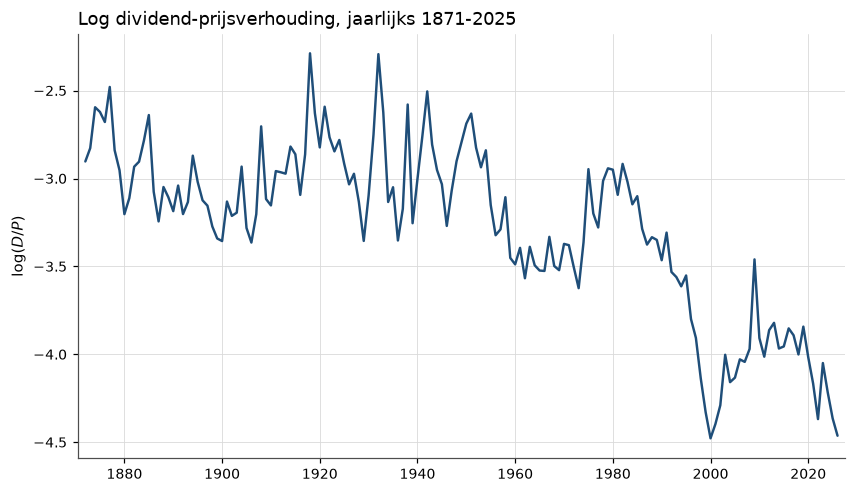

In [7]:
fig, ax = plt.subplots()
ax.plot(gw.index, gw["dp"])
ax.set_title("Log dividend-prijsverhouding, jaarlijks 1871-2025")
ax.set_xlabel("Jaar")
ax.set_ylabel("$\\log(D/P)$")
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-gw
:label: fig-setup-gw
:width: 90%

De log dividend-prijsverhouding is extreem persistent: hij beweegt over
decennia, niet over jaren. Die persistentie is de reden dat regressies met deze
variabele als voorspeller een bias hebben en dat hun $t$-waarden niet mogen
worden gelezen als gewone $t$-waarden.
:::

### FRED: de macrocontext

FRED van de Federal Reserve Bank of St. Louis levert alles wat de markt
omringt: consumptie, inflatie, rentes, wisselkoersen, credit spreads, de VIX,
en de NBER-recessie-indicator waarmee `hap.plotting.recession_shading`
grijze banden in een figuur zet. Eén serie per aanroep, met FRED's eigen
eenheden.

In [8]:
vix = hap_data.fred("VIXCLS")
vix.describe().round(2)

,VIXCLS
count,9266.00
mean,19.43
std,7.72
min,9.14
25%,13.99
50%,17.58
75%,22.68
max,82.69


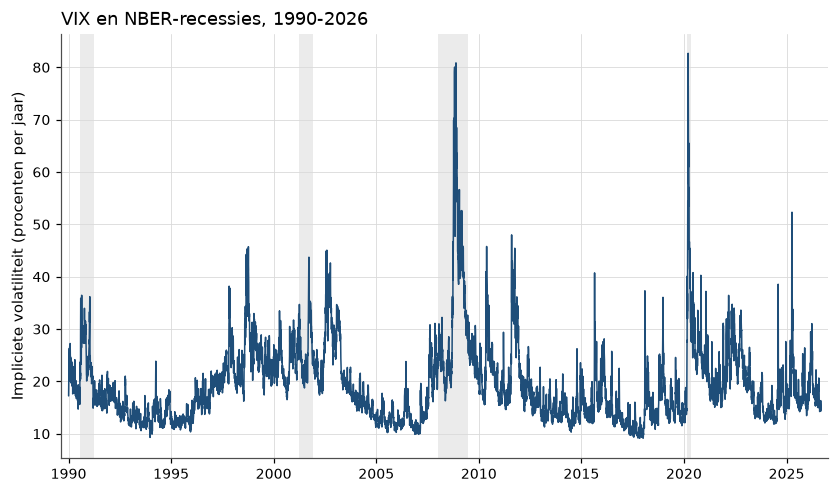

In [9]:
series = vix["VIXCLS"].dropna()

fig, ax = plt.subplots()
ax.plot(series.index, series, lw=1.0)
ax.set_title("VIX en NBER-recessies, 1990-2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("Impliciete volatiliteit (procenten per jaar)")
hap.plotting.timeline_axis(ax)
hap.plotting.recession_shading(ax)
plt.show()

:::{figure} #cel-setup-fred
:label: fig-setup-fred
:width: 90%

De VIX is de door de optiemarkt verwachte volatiliteit van de S&P 500 over de
komende maand. Hij piekt in recessies (grijs) maar niet alleen daar: maart 2020
en oktober 2008 zijn zichtbaar, en 1998 en 2018 ook. Anders dan het gemiddelde
rendement is volatiliteit een grootheid die zichtbaar clustert — en daarom
voorspelbaar is.
:::

### Gürkaynak-Sack-Wright: de yieldcurve

De Federal Reserve publiceert dagelijks een geschatte zero-coupon yieldcurve op
basis van de Svensson-parametrisatie, terug tot 1961
{cite}`GurkaynakSackWright2007`. `hap.gsw()` geeft de kolommen `SVENYnn`
(zero-coupon yield op $nn$ jaar), `SVENFnn` (instantane forward) en de
onderliggende parameters, alles als decimalen.

In [10]:
gsw = hap_data.gsw()
maturities = [f"SVENY{n:02d}" for n in range(1, 31)]
gsw.loc[["1981-09-30", "2020-08-04", "2026-08-28"], ["SVENY01", "SVENY05", "SVENY10"]].round(4)

,SVENY01,SVENY05,SVENY10
date,,,
1981-09-30,0.1569,0.1518,0.1489
2020-08-04,0.0013,0.0022,0.0052
2026-08-28,0.0420,0.0448,0.0480


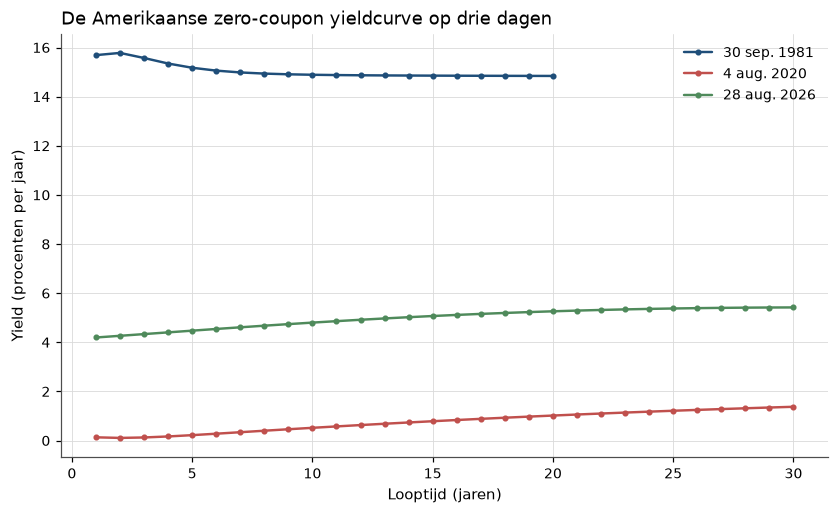

In [11]:
fig, ax = plt.subplots()
for date, label in [("1981-09-30", "30 sep. 1981"),
                    ("2020-08-04", "4 aug. 2020"),
                    ("2026-08-28", "28 aug. 2026")]:
    curve = gsw.loc[date, maturities].dropna()
    ax.plot(range(1, len(curve) + 1), curve.to_numpy() * 100, marker="o",
            ms=3, label=label)
ax.set_title("De Amerikaanse zero-coupon yieldcurve op drie dagen")
ax.set_xlabel("Looptijd (jaren)")
ax.set_ylabel("Yield (procenten per jaar)")
ax.legend()
plt.show()

:::{figure} #cel-setup-gsw
:label: fig-setup-gsw
:width: 90%

Drie curves die het bereik van de reeks laten zien: september 1981, met een
eenjaarsrente van 15,7% en een dalende curve; augustus 2020, met een
eenjaarsrente van 0,13%; en augustus 2026. De vorm van de curve — niet alleen
het niveau — draagt informatie over toekomstige rendementen.
:::

### Open Source Asset Pricing: de factor zoo, gedocumenteerd

Chen en Zimmermann bouwden de gepubliceerde cross-sectionele anomalieën na
volgens de recepten van de originele papers, en publiceerden zowel de
maandelijkse long-short-rendementen als een documentatiebestand met per signaal
de auteurs, het publicatiejaar, de steekproefperiode en de gerapporteerde
$t$-waarde {cite}`ChenZimmermann2022`. Dat tweede bestand is precies wat je
nodig hebt om na te gaan of factoren na publicatie blijven werken.

In [12]:
signaldoc = hap_data.osap("signaldoc")
predictors = signaldoc[signaldoc["Cat.Signal"] == "Predictor"]
predictors[["signal", "Authors", "Year", "Journal", "T-Stat"]].head(5)

,signal,Authors,Year,Journal,T-Stat
date,,,,,
2001-12-31,AbnormalAccruals,Xie,2001,AR,8.43
1996-12-31,Accruals,Sloan,1996,AR,4.71
2004-12-31,AccrualsBM,Bartov and Kim,2004,RFQA,5.50
2005-12-31,Activism1,Cremers and Nair,2005,JF,3.13
1992-12-31,AM,Fama and French,1992,JF,5.69


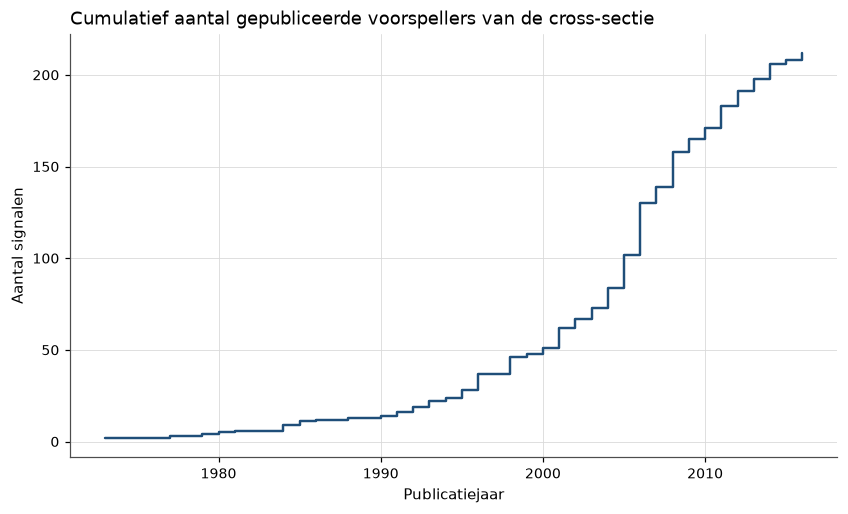

In [13]:
per_year = predictors.index.year.value_counts().sort_index()

fig, ax = plt.subplots()
ax.step(per_year.index, per_year.cumsum(), where="post")
ax.set_title("Cumulatief aantal gepubliceerde voorspellers van de cross-sectie")
ax.set_xlabel("Publicatiejaar")
ax.set_ylabel("Aantal signalen")
plt.show()

:::{figure} #cel-setup-osap
:label: fig-setup-osap
:width: 90%

Van een handvol anomalieën in de jaren zeventig naar meer dan tweehonderd
gereproduceerde signalen. De mediane gepubliceerde $t$-waarde in deze
verzameling is 4,0 — ruim boven de gebruikelijke drempel van 1,96, en dat is
geen toeval maar een selectie-effect {cite}`HarveyLiuZhu2016`.
:::

### He-Kelly-Manela: het kapitaal van de tussenpersoon

Na 2008 kwam er een klasse modellen waarin niet de gemiddelde belegger de
prijzen zet maar de gefinancierde tussenpersoon: de dealer, de hedgefondsdesk,
de bank. He, Kelly en Manela construeerden de kapitaalratio van de primary
dealers en het bijbehorende risicofactorrendement, en lieten zien dat die
factor rendementen in veel activaklassen tegelijk prijst
{cite}`HeKellyManela2017`.

In [14]:
hkm = hap_data.hkm("monthly")
hkm.tail(3).round(4)

,intermediary_capital_ratio,intermediary_capital_risk_factor,intermediary_value_weighted_investment_return,intermediary_leverage_ratio_squared
date,,,,
2025-03-31,0.0745,-0.0944,-0.0661,180.2846
2025-04-30,0.0739,-0.0051,-0.0092,183.3444
2025-05-31,0.0791,0.0742,0.0833,159.8318


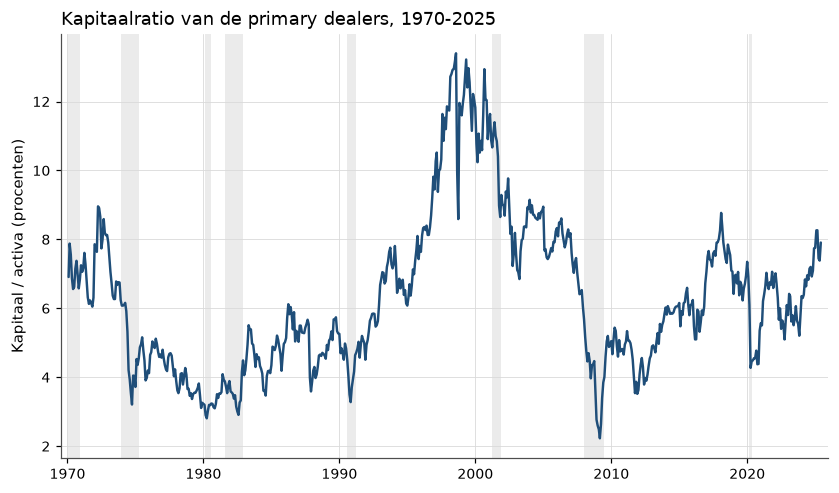

In [15]:
ratio = hkm["intermediary_capital_ratio"]

fig, ax = plt.subplots()
ax.plot(ratio.index, ratio * 100)
ax.set_title("Kapitaalratio van de primary dealers, 1970-2025")
ax.set_xlabel("Jaar")
ax.set_ylabel("Kapitaal / activa (procenten)")
hap.plotting.timeline_axis(ax)
hap.plotting.recession_shading(ax)
plt.show()

:::{figure} #cel-setup-hkm
:label: fig-setup-hkm
:width: 90%

De kapitaalratio van de tussenpersonen bereikt zijn laagste punt van de hele
reeks in februari 2009, op 2,2%. In modellen van intermediary asset pricing is
dat geen bijzaak maar de toestandsvariabele: als de balans van de dealer krimpt,
stijgt de vereiste vergoeding voor elk risico dat hij moet dragen.
:::

### Yahoo Finance: recente koersen en optieketens

Voor alles wat na 1993 gebeurt en op dagniveau moet — event studies,
illiquiditeitsmaten, optieketens — gebruiken we Yahoo Finance via `yfinance`.
De cache bevat de dagelijkse, voor splitsingen en dividenden gecorrigeerde
slotkoersen van vijf ETF's en één momentopname van de optieketen van SPY.
Yahoo is de enige onbetrouwbare bron in de lijst: rate limits en incidentele
lege downloads horen erbij, en het is geen historisch archief maar de huidige
stand. Vraag daarom in een lecture uitsluitend op wat al in de cache staat.

In [16]:
etf = hap_data.yahoo(["SPY", "TLT", "GLD", "QQQ", "IWM"], "1993-01-01")
etf.dropna(how="all").iloc[[0, -1]].round(2)

,GLD,IWM,QQQ,SPY,TLT
date,,,,,
1993-01-29,NaN,NaN,NaN,24.11,NaN
2026-09-04,406.77,296.01,718.96,770.19,82.21


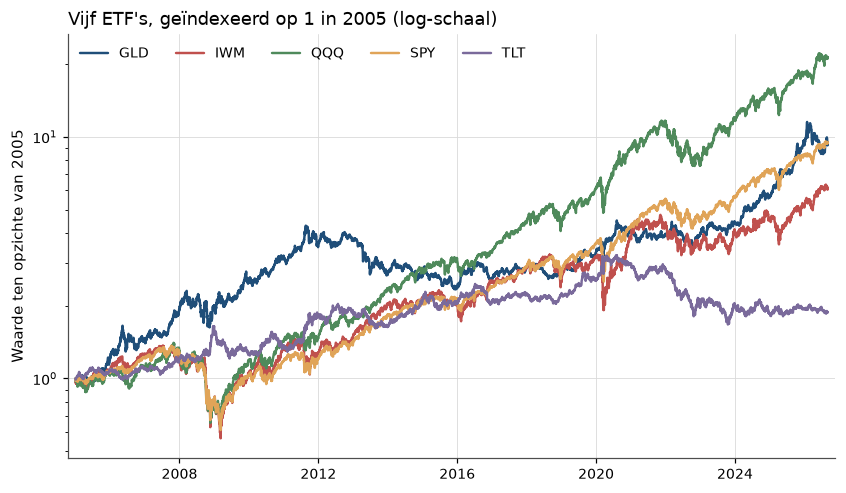

In [17]:
recent = etf.loc["2005-01-01":].dropna()
normalised = recent / recent.iloc[0]

fig, ax = plt.subplots()
for column in normalised.columns:
    ax.plot(normalised.index, normalised[column], label=column)
ax.set_yscale("log")
ax.set_title("Vijf ETF's, geïndexeerd op 1 in 2005 (log-schaal)")
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde ten opzichte van 2005")
ax.legend(ncols=5)
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-yahoo
:label: fig-setup-yahoo
:width: 90%

Aandelen (SPY, QQQ, IWM), langlopende staatsobligaties (TLT) en goud (GLD)
vanaf 2005. Het is verleidelijk hier conclusies uit te trekken over verwachte
rendementen; bij een volatiliteit van 18% per jaar hoort bij twintig jaar data
een standaardfout van het gemiddelde van ongeveer vier procentpunt, en dat is
groter dan zowat elk verschil dat u in deze figuur meent te zien.
:::

### Wat we niet hebben: CRSP en Compustat

Twee namen komen in deze reeks voortdurend voor zonder dat we ze ooit openen.

*CRSP* is het Center for Research in Security Prices van de Universiteit van
Chicago. Het bouwde vanaf 1960, in opdracht en met geld van Merrill Lynch, de
eerste machine-leesbare reeks van maandrendementen van alle aandelen aan de New
York Stock Exchange terug tot 1926 — inclusief dividenden, splitsingen en, wat
cruciaal is, de aandelen die van de beurs verdwenen. Zonder die laatste categorie
meet je alleen de overlevenden. De eerste publicatie op die tape
{cite}`FisherLorie1964` was tegelijk de eerste betrouwbare meting van het
gemiddelde rendement op Amerikaanse aandelen over een lange periode. *Compustat*
doet hetzelfde voor de boekhouding: balans- en winst-en-verliesgegevens per
bedrijf per kwartaal, en daarmee de noemer van elke waarderingsratio.

Allebei zijn ze commercieel en duur, meestal toegankelijk via WRDS en dus via
een universiteitsabonnement. Deze reeks gebruikt ze niet. Dat kost ons iets
reëels: we kunnen niets doen op het niveau van het individuele aandeel — geen
eigen sorteringen, geen eigen portefeuilleconstructie, geen event study op een
brede steekproef. Wat we ervoor terugkrijgen is dat elke lecture draait op een
laptop zonder abonnement.

De compensatie is dat de belangrijkste bewerkingen al voor ons zijn gedaan.
Kenneth French publiceert de portefeuilles die uit CRSP en Compustat zijn
gebouwd — dat is precies wat de Data Library is — en Chen en Zimmermann
publiceren de long-short-rendementen van de anomalieën. We erven daarmee hun
constructiekeuzes, en waar dat uitmaakt zeggen we dat in het replicatieblok.
Waar zelfs dat niet volstaat, simuleren we, en dan staat er expliciet bij welke
eigenschap van de echte data de simulatie nabootst.

## De gereedschapskist: `hap.stats` en `hap.plotting`

Naast de loaders bevat `hap` twee kleine modules. In `hap.stats` staan de
schatters die in deze literatuur standaard zijn: `newey_west` (OLS met
HAC-standaardfouten), `fama_macbeth`, `grs_test`, `long_horizon_regression`,
`variance_ratio`, `hansen_jagannathan_bound`, `sharpe`, `drawdowns` en
`summary_stats`. Ze werken allemaal op gewone pandas-objecten en gaan ervan uit
dat rendementen decimalen per periode zijn.

Eén voorbeeld, dat meteen een resultaat uit Deel IV vooruitloopt: voorspelt de
log dividend-prijsverhouding het rendement van het volgende jaar? We regresseren
de equity premium van jaar $t+1$ op $\mathrm{dp}_t$, met Newey-West-standaardfouten.

In [18]:
panel = pd.DataFrame(
    {"ep_next": gw["equity_premium"].shift(-1), "dp": gw["dp"]}
).dropna()
fit = hap.newey_west(panel["ep_next"], panel[["dp"]], lags=1)

pd.DataFrame(
    {"coëfficiënt": fit.params, "standaardfout": fit.bse, "t-waarde": fit.tvalues}
).round(4)

,coëfficiënt,standaardfout,t-waarde
const,0.2103,0.1580,1.3307
dp,0.0423,0.0444,0.9526


De helling is positief — een hoog dividendrendement gaat samen met een hoger
rendement daarna, zoals de theorie van tijdvariërende discontovoeten voorspelt
— maar met een $t$-waarde van ongeveer 0,95 en een $R^2$ van iets meer dan één
procent op honderd jaarobservaties is dat geen bewijs van iets. Precies dat
spanningsveld, tussen een teken dat klopt en een standaardfout die te groot is,
is het onderwerp van een groot deel van deze reeks.

`hap.plotting` is kleiner: `setup()` zet de projectstijl (die staat in de
imports-cel en wordt daarna nooit meer aangeraakt), `timeline_axis(ax)` maakt
van een datum-as een kalenderjaar-as, `recession_shading(ax)` zet de
NBER-recessies als grijze banden achter een figuur, en `COLORS` is het vaste
kleurenpalet. Elke figuur in deze reeks heeft een titel en aslabels in het
Nederlands.

## Hoe u zelf werkt

Het project wordt beheerd met `uv`. Alle Python-commando's lopen daarom via
`uv run`, dat de virtuele omgeving en de afhankelijkheden uit `pyproject.toml`
op orde houdt zonder dat u zelf iets hoeft te activeren:

```bash
uv run jupyter book start          # live meekijken op localhost:3000
uv run jupyter book build --html   # de statische site bouwen
uv run pytest -q                   # de testsuite (draait offline)
```

Elke lecture bestaat twee keer: als MyST-markdown (`lectures/00_00_setup.md`)
en als notebook (`lectures/00_00_setup.ipynb`). Jupytext houdt ze gepaard. De
markdown is de bron van waarheid voor de tekst, het notebook is waar u code
uitprobeert en debugt; werkt u in het notebook, synchroniseer dan terug voordat
u iets anders doet:

```bash
uv run jupytext --sync lectures/00_00_setup.md
uv run jupytext --execute --to ipynb lectures/00_00_setup.md
```

Voor de data is er één omgevingsvariabele die u moet kennen. `HAP_OFFLINE=1`
verbiedt elke download: de loaders lezen uitsluitend uit `data/cache/`, en een
ontbrekende snapshot geeft een `hap.CacheMissError` in plaats van stilzwijgend
nieuwe data. Zo draait de testsuite, en zo is elke lecture in deze reeks
uitgevoerd. `HAP_REFRESH=1` doet het omgekeerde en haalt een verse snapshot op.
Zonder een van beide wordt er alleen gedownload als het parquet-bestand
ontbreekt — snapshots verlopen dus nooit vanzelf, en een figuur die u vandaag
maakt ziet er morgen hetzelfde uit.

```{warning}
Een reeks die per uitvoering verandert, is niet reproduceerbaar. Ververs een
snapshot bewust, met `HAP_REFRESH=1` en een aantekening erbij, en niet als
bijvangst van een lecture die u toevallig draait.
```

## Een eerste meting: het gemiddelde en zijn standaardfout

*Waarom zou dit waar zijn?* Een rendement is de uitkomst van één trekking uit
een verdeling. Het gemiddelde van $T$ trekkingen schat het midden van die
verdeling, maar de nauwkeurigheid van die schatting hangt alleen af van de
spreiding en het aantal trekkingen: $\SD(\bar r) = \sigma/\sqrt{T}$. Voor
aandelen is $\sigma$ groot ten opzichte van $\mu$ — ongeveer 18% tegenover
ongeveer 11% — en daar loopt de hele empirische asset pricing tegenaan. Het
probleem is niet dat we te weinig geschiedenis hebben; het probleem is dat
honderd jaar geschiedenis honderd trekkingen zijn.

Neem een gesimuleerde markt met een waar gemiddelde van 8% en een ware
volatiliteit van 20% per jaar, honderd jaar lang. Wat schat één zo'n eeuw?

In [19]:
mu_true, sigma_true, n_years = 0.08, 0.20, 100
one_century = rng.normal(mu_true, sigma_true, n_years)

mean_hat = one_century.mean()
se_hat = one_century.std(ddof=1) / np.sqrt(n_years)

pd.DataFrame(
    {
        "waarde": [mu_true, mean_hat, se_hat, mean_hat - 1.96 * se_hat,
                   mean_hat + 1.96 * se_hat],
    },
    index=["waar gemiddelde", "geschat gemiddelde", "standaardfout",
           "ondergrens 95%", "bovengrens 95%"],
).round(4)

,waarde
waar gemiddelde,0.0800
geschat gemiddelde,0.0846
standaardfout,0.0203
ondergrens 95%,0.0449
bovengrens 95%,0.1243


Eén steekproef zegt weinig; de vraag is hoe de schatter zich over steekproeven
gedraagt. Tienduizend keer een eeuw geeft de verdeling van $\bar r$, en ter
vergelijking de verdeling van $\hat\sigma$.

In [20]:
n_sim = 10_000
samples = rng.normal(mu_true, sigma_true, size=(n_sim, n_years))
means = samples.mean(axis=1)
sds = samples.std(axis=1, ddof=1)

pd.DataFrame(
    {
        "gemiddelde van de schatter": [means.mean(), sds.mean()],
        "std.dev. van de schatter": [means.std(ddof=1), sds.std(ddof=1)],
        "relatieve fout": [means.std(ddof=1) / mu_true, sds.std(ddof=1) / sigma_true],
    },
    index=["gemiddeld rendement", "volatiliteit"],
).round(4)

,gemiddelde van de schatter,std.dev. van de schatter,relatieve fout
gemiddeld rendement,0.0797,0.0200,0.2498
volatiliteit,0.1996,0.0142,0.0709


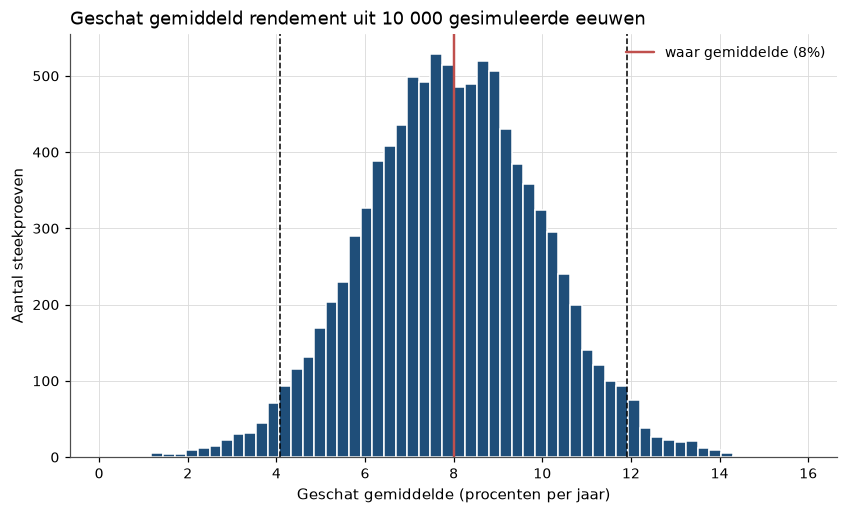

In [21]:
fig, ax = plt.subplots()
ax.hist(means * 100, bins=60, edgecolor="white")
ax.axvline(mu_true * 100, color=hap.plotting.COLORS[1], lw=1.6,
           label="waar gemiddelde (8%)")
for side in (-1, 1):
    ax.axvline((mu_true + side * 1.96 * sigma_true / np.sqrt(n_years)) * 100,
               color="black", ls="--", lw=1.0)
ax.set_title("Geschat gemiddeld rendement uit 10 000 gesimuleerde eeuwen")
ax.set_xlabel("Geschat gemiddelde (procenten per jaar)")
ax.set_ylabel("Aantal steekproeven")
ax.legend()
plt.show()

:::{figure} #cel-setup-se
:label: fig-setup-se

De verdeling van het gemiddelde rendement over tienduizend gesimuleerde eeuwen.
De stippellijnen liggen twee standaardfouten van de waarheid af, op ongeveer 4%
en 12%. Een onderzoeker met honderd jaar data en een perfect gespecificeerd
model weet dus nog steeds niet of de premie 4% of 12% is.
:::

De volatiliteit wordt in dezelfde simulatie met een relatieve fout van ongeveer
7% geschat, het gemiddelde met een relatieve fout van ongeveer 25%. Dat is de
asymmetrie in één beeld. Ze is geen eigenschap van deze simulatie maar van de
grootte-orde van $\mu$ en $\sigma$ zelf, en ze verandert niet door slimmer te
schatten: alleen door meer, of fijnere, data — en fijnere data helpt alleen
voor de variantie, niet voor het gemiddelde. Waarom dat laatste zo is, en wat
er precies gebeurt als we van maand- naar dagdata gaan, is het onderwerp van de
volgende lecture.

Ter controle van de orde van grootte: de echte markt gaf hierboven 11,6%
gemiddeld met een standaardfout van 1,8 procentpunt over 1201 maanden. De
simulatie met $\sigma = 20\%$ geeft 2,0 procentpunt. Het beroemde getal is dus
geen metafoor maar een rekensom die u zojuist twee keer hebt gemaakt.

## Wat er daarna komt

De gereedschapskist staat klaar: acht databronnen die offline draaien, een
notatie die de hele reeks volhoudt, en een handvol schatters. Wat nog ontbreekt
is het begrip waar alles op rust. We hebben in deze lecture doodleuk
"rendementen" opgeteld, gemiddeld en geannualiseerd zonder te zeggen wat een
rendement is, of het meetkundig of rekenkundig gemiddelde het antwoord op uw
vraag is, wanneer $\sqrt{t}$-schaling mag, en waarom de standaardfout van het
gemiddelde niet kleiner wordt als u dagdata gebruikt terwijl die van de
variantie dat wel doet.

Dat is de inhoud van [Rendementen en hun statistiek](#00-01-rendementen): log- versus simpele rendementen,
annualisatie, de wortel-$t$-regel en waar hij vandaan komt, de standaardfout van
het gemiddelde in vol ornaat, autocorrelatie en dikke staarten. Daarna begint
het verhaal echt, in 1863, bij een man in Parijs die op de beurs werkte en
opmerkte dat de koersuitslag met de wortel van de tijd toenam.

## Oefeningen

:::{exercise}
:label: ex-setup-1

**Een loader gebruiken en een grootheid berekenen.** Laad de tien
industrieportefeuilles van French met
`hap_data.french("10_Industry_Portfolios", "monthly")` en beperk de steekproef
tot 1970 en later.

1. Bereken per industrie het geannualiseerde gemiddelde rendement, de
   geannualiseerde standaarddeviatie en de standaardfout van het gemiddelde.
   Gebruik `hap.summary_stats`.
2. Welke industrie heeft het hoogste gemiddelde, en welke het laagste? Hoeveel
   procentpunt schelen ze?
3. Bereken de standaardfout van dat *verschil* onder de (onjuiste) aanname dat
   de twee reeksen ongecorreleerd zijn, en toets of het verschil twee
   standaardfouten haalt. Wat leert dat over rangordes van gemiddelde
   rendementen?
:::

:::{solution} ex-setup-1
:class: dropdown

In [22]:
industries = hap_data.french("10_Industry_Portfolios", "monthly").loc["1970":]
table = hap.summary_stats(industries, "monthly")[
    ["nobs", "mean_ann", "std_ann", "se_mean_ann"]
]
table.sort_values("mean_ann", ascending=False).round(4)

,nobs,mean_ann,std_ann,se_mean_ann
Enrgy,679,0.131553,0.217982,0.028979
HiTec,679,0.130047,0.225771,0.030014
Shops,679,0.129577,0.181881,0.024179
Durbl,679,0.127674,0.266757,0.035463
NoDur,679,0.122545,0.148567,0.019751
Hlth,679,0.121811,0.16813,0.022351
Manuf,679,0.121085,0.177132,0.023548
Other,679,0.114765,0.184634,0.024545
Utils,679,0.109741,0.143102,0.019024
Telcm,679,0.104266,0.1675,0.022267


In [23]:
best, worst = table["mean_ann"].idxmax(), table["mean_ann"].idxmin()
gap = table.loc[best, "mean_ann"] - table.loc[worst, "mean_ann"]
se_gap = np.sqrt(table.loc[best, "se_mean_ann"] ** 2 + table.loc[worst, "se_mean_ann"] ** 2)

pd.DataFrame(
    {"waarde": [gap, se_gap, gap / se_gap]},
    index=[f"verschil {best} - {worst}", "standaardfout van het verschil", "t-waarde"],
).round(4)

,waarde
verschil Enrgy - Telcm,0.0273
standaardfout van het verschil,0.0365
t-waarde,0.7467


Het verschil tussen de beste en de slechtste industrie over meer dan vijftig
jaar is een paar procentpunt per jaar, met een standaardfout in dezelfde orde
van grootte. Zelfs de *extremen* van tien portefeuilles over een halve eeuw zijn
dus nauwelijks te onderscheiden, en de aanname van nulcorrelatie maakt de
standaardfout hier nog te klein: industrieportefeuilles zijn sterk gecorreleerd,
en die correlatie werkt door in de spreiding van het verschil. Wie een rangorde
van gemiddelde rendementen serieus neemt, neemt ruis serieus.
:::

:::{exercise}
:label: ex-setup-2

**Hoeveel data is genoeg?** Gebruik `hap_data.market_monthly()`.

1. Splits de steekproef in 1926–1975 en 1976–2026 en bereken voor beide helften
   het geannualiseerde gemiddelde excess rendement met standaardfout. Verschilt
   het gemiddelde significant tussen de twee helften?
2. Hoeveel jaar data zou u nodig hebben om het gemiddelde excess rendement tot
   op 0,5 procentpunt nauwkeurig te kennen, bij de waargenomen volatiliteit?
3. Herhaal (2) voor de standaarddeviatie, met
   $\SD(\hat\sigma) \approx \sigma/\sqrt{2T}$. Vergelijk de twee antwoorden.
:::

:::{solution} ex-setup-2
:class: dropdown

In [24]:
excess = hap_data.market_monthly()["Mkt-RF"]
halves = pd.concat(
    [
        hap.summary_stats(excess.loc[:"1975"].rename("1926-1975"), "monthly"),
        hap.summary_stats(excess.loc["1976":].rename("1976-2026"), "monthly"),
    ]
)[["nobs", "mean_ann", "std_ann", "se_mean_ann"]]
halves.round(4)

,nobs,mean_ann,std_ann,se_mean_ann
1926-1975,594,0.079572,0.209395,0.029762
1976-2026,607,0.086928,0.154689,0.02175


In [25]:
diff = halves.loc["1926-1975", "mean_ann"] - halves.loc["1976-2026", "mean_ann"]
se_diff = np.sqrt(
    halves.loc["1926-1975", "se_mean_ann"] ** 2 + halves.loc["1976-2026", "se_mean_ann"] ** 2
)

sigma = float(hap.summary_stats(excess, "monthly").loc["Mkt-RF", "std_ann"])
years_mean = (sigma / 0.005) ** 2
years_sd = sigma**2 / (2 * 0.005**2)

pd.DataFrame(
    {"waarde": [diff, se_diff, diff / se_diff, years_mean, years_sd]},
    index=[
        "verschil tussen de helften",
        "standaardfout van het verschil",
        "t-waarde",
        "jaren nodig voor SE(gemiddelde) = 0,5pp",
        "jaren nodig voor SE(std.dev.) = 0,5pp",
    ],
).round(3)

,waarde
verschil tussen de helften,-0.007
standaardfout van het verschil,0.037
t-waarde,-0.200
"jaren nodig voor SE(gemiddelde) = 0,5pp",1350.104
"jaren nodig voor SE(std.dev.) = 0,5pp",675.052


De twee helften van de eeuw verschillen met een $t$-waarde ver onder twee: de
data kan niet uitmaken of de equity premium na de oorlog is veranderd. Om het
gemiddelde tot op een halve procentpunt te kennen zijn ongeveer dertienhonderd
jaar nodig — meer dan er beurzen bestaan. Voor de standaarddeviatie volstaan
ongeveer zevenhonderd jaar met *jaardata*, en dat is nog steeds veel; het
verschil is dat de variantie wél profiteert van fijnere waarneming binnen het
jaar en het gemiddelde niet. Waarom dat zo is, staat in
[Rendementen en hun statistiek](#00-01-rendementen).
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->